### Import Necessary Libraries

In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import scale

#### Parse Data

In [ ]:
# parse data
df = pd.read_csv("retail_transactions.csv", encoding='iso-8859-1')
df['item_total'] = df['Quantity'] * df['UnitPrice']
dfnew = df.groupby('CustomerID').agg({'InvoiceNo': 'nunique', 'item_total': 'sum'})
dfnew.rename(columns={'InvoiceNo': 'invoice_count', 'item_total': 'amt_total'}, inplace=True)
X = scale(dfnew[['invoice_count', 'amt_total']])

### Create Functions for Kmeans and DbScan

In [8]:
def cluster_kMeans(X,k):
  mdlKmcRtc = KMeans(n_clusters=k, random_state=1)
  mdlKmcRtc.fit(X)
  kmeans_labels = mdlKmcRtc.labels_
  kmeans_sil_score = silhouette_score(X, kmeans_labels)
  return kmeans_labels, kmeans_sil_score

In [ ]:

def cluster_DBScan(X,e):
  mdlDbsRtc = DBSCAN(eps=e)
  mdlDbsRtc.fit(X)
  dbscan_labels_e = mdlDbsRtc.labels_
  dbscan_sil_score_e = silhouette_score(X, dbscan_labels_e)
  dbscan_clusters_e = len(set(dbscan_labels_e))-(1 if -1 in dbscan_labels_e else 0)
  dbscan_anomalies_e = len(dbscan_labels_e[dbscan_labels_e==-1])
  return dbscan_labels_e, dbscan_sil_score_e, dbscan_clusters_e, dbscan_anomalies_e

### Try different K and e Values

In [11]:
for k in [2,3,4,5,6]:
  kmeans_sil_score_best = 0
  kmeans_labels_k, kmeans_sil_score_k = cluster_kMeans(X,k)
  if kmeans_sil_score_k > kmeans_sil_score_best:
    kmeans_labels = kmeans_labels_k
    kmeans_sil_score_best = kmeans_sil_score_k
  print('k:',k, '\t\t','sil_score:',kmeans_sil_score_k)

for e in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.5,2.0,2.5,3.0,4.0,5.0,6.0,7.0,8.0,9.0]:
  dbscan_sil_score_best = 0
  dbscan_labels_e, dbscan_sil_score_e, dbscan_clusters_e, dbscan_anomalies_e = cluster_DBScan(X,e)
  if dbscan_sil_score_e > dbscan_sil_score_best:
    dbscan_labels = dbscan_labels_e
    dbscan_sil_score_best = dbscan_sil_score_e
  print('eps:',e, '\t\t','sil_score:',dbscan_sil_score_e, '\t\t','clusters:',dbscan_clusters_e, '\t\t','anomalies:',dbscan_anomalies_e)


k: 2 		 sil_score: 0.9503432954038323
k: 3 		 sil_score: 0.8229586806895549
k: 4 		 sil_score: 0.7675493870106322
k: 5 		 sil_score: 0.7514378910638715
k: 6 		 sil_score: 0.7299224375528661
eps: 0.1 		 sil_score: 0.44303062146907807 		 clusters: 24 		 anomalies: 235
eps: 0.2 		 sil_score: 0.8835745228080347 		 clusters: 1 		 anomalies: 110
eps: 0.3 		 sil_score: 0.9082453438451032 		 clusters: 1 		 anomalies: 75
eps: 0.4 		 sil_score: 0.8723010302239043 		 clusters: 2 		 anomalies: 60
eps: 0.5 		 sil_score: 0.8277387470113158 		 clusters: 3 		 anomalies: 43
eps: 0.6 		 sil_score: 0.8260463106415202 		 clusters: 3 		 anomalies: 34
eps: 0.7 		 sil_score: 0.8336443702741331 		 clusters: 2 		 anomalies: 32
eps: 0.8 		 sil_score: 0.9460932490176458 		 clusters: 1 		 anomalies: 30
eps: 0.9 		 sil_score: 0.9472191707848616 		 clusters: 1 		 anomalies: 29
eps: 1.0 		 sil_score: 0.9472191707848616 		 clusters: 1 		 anomalies: 29
eps: 1.5 		 sil_score: 0.9502179515979182 		 clusters: 1 		 anomal

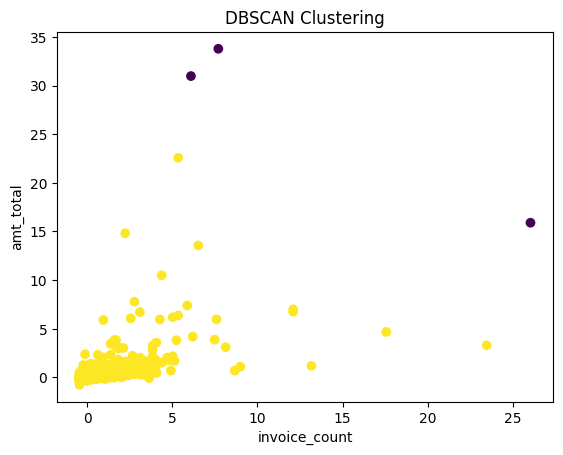

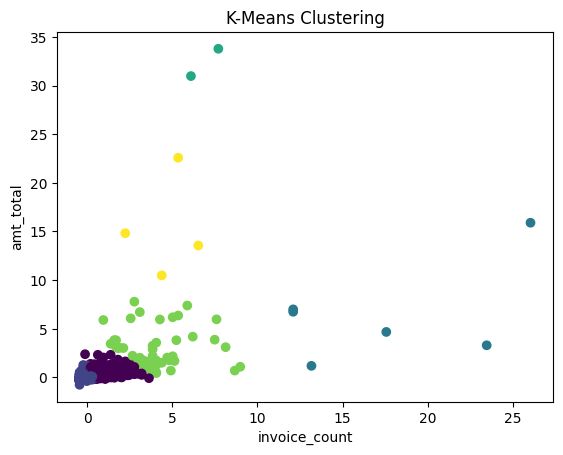

In [12]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1],c=dbscan_labels)
plt.xlabel('invoice_count')
plt.ylabel('amt_total')
plt.title('DBSCAN Clustering')
plt.show()

plt.scatter(X[:,0], X[:,1],c=kmeans_labels)
plt.xlabel('invoice_count')
plt.ylabel('amt_total')
plt.title('K-Means Clustering')
plt.show()